# Library Used

In [37]:
# importing libraries
import numpy as np
import cv2
from skimage import color
from skimage.transform import rescale
from matplotlib import image
import matplotlib.pyplot as plt
from keras.models import Sequential,load_model,Model
from keras.layers import Conv2D,MaxPool2D,Dense,Dropout,BatchNormalization,Flatten,Input
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn import metrics
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR


The script imports necessary libraries, including glob for file matching, os for operating system-related tasks, io and color from skimage for image loading and manipulation, and rescale for image resizing. matplotlib.pyplot is used for visualization.

# Convert colored face images to grayscale images and resize to 50 by50 pixels

# Question 1 and 2

age: 100
gender: 1


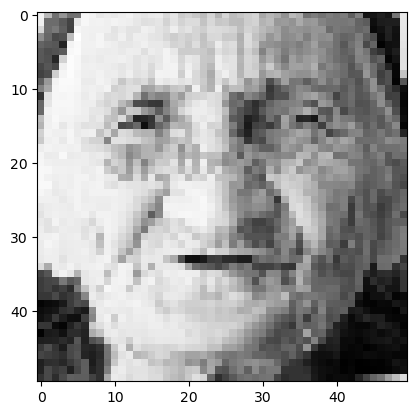

age: 100
gender: 1


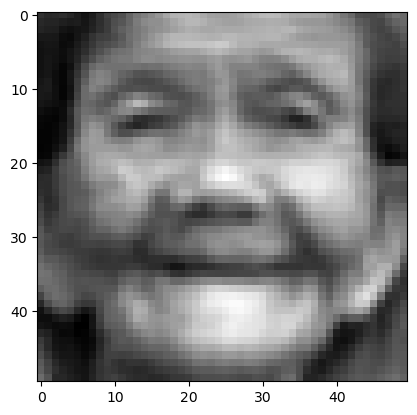

age: 101
gender: 1


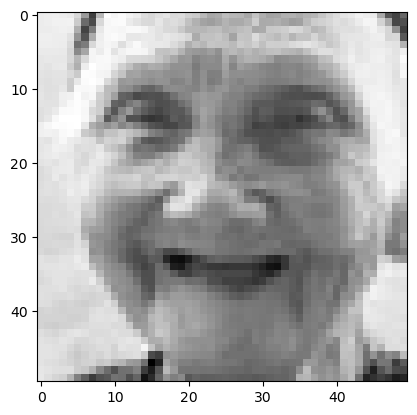

age: 10
gender: 0


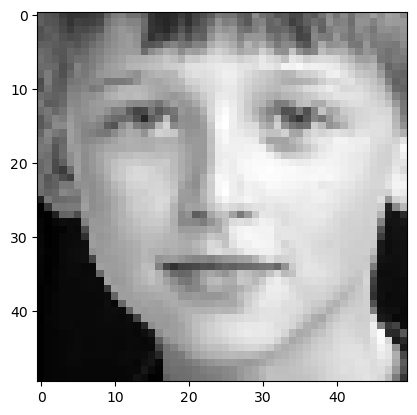

age: 10
gender: 0


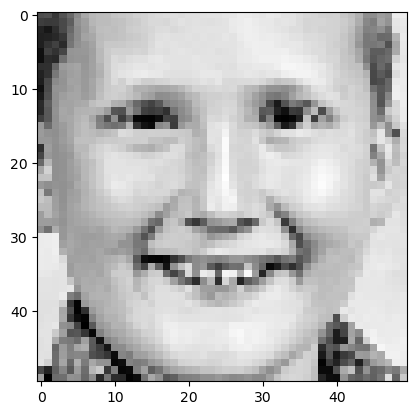

age: 10
gender: 0


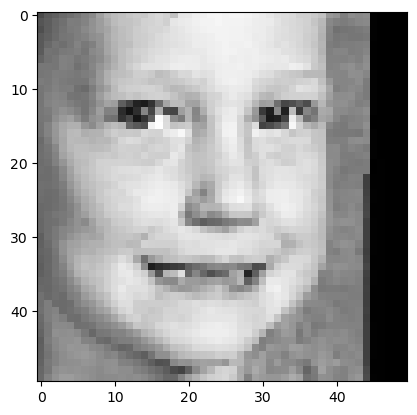

age: 10
gender: 0


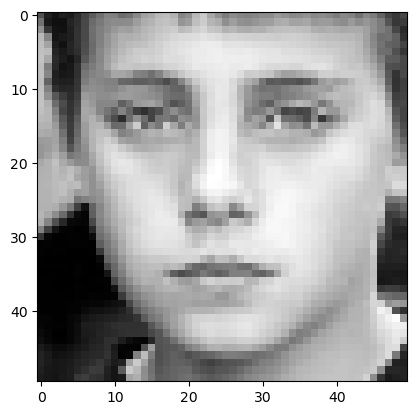

age: 10
gender: 0


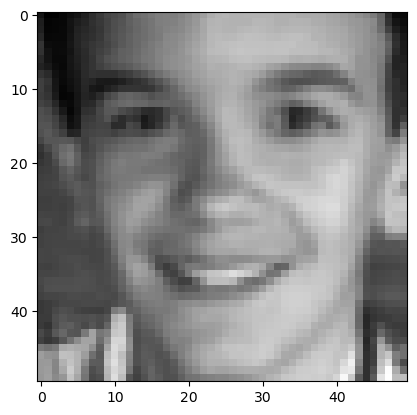

age: 10
gender: 0


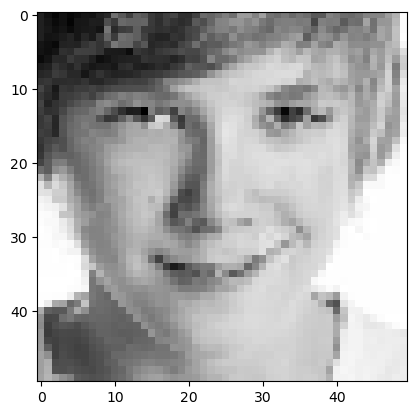

age: 10
gender: 0


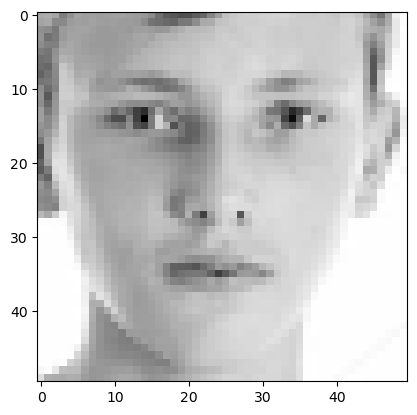

age: 10
gender: 0


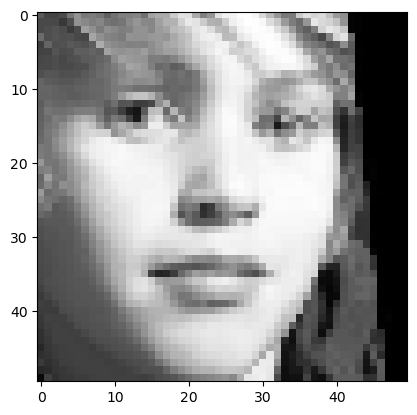

age: 10
gender: 0


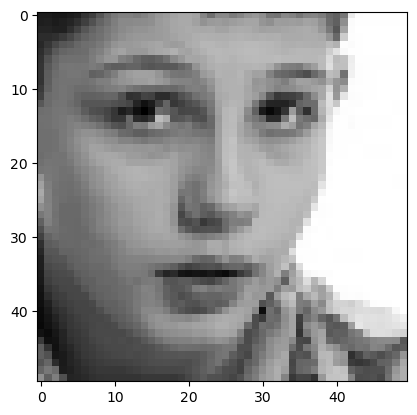

In [166]:
import glob
import os

#Three empty lists
Faces =[]
Ages = []
Genders = []
# Visualize some examples of resize image
for k,i in enumerate(glob.glob(r"FaceData/*")):

    # load image
    imagei = image.imread(i)
    print("age:",os.path.basename(i).split("_")[0])
    print("gender:",os.path.basename(i).split("_")[1]) #male 0, female 1
    Ages.append(os.path.basename(i).split("_")[0])
    Genders.append(os.path.basename(i).split("_")[1])

    # Convert to grayscale images
    imagei = color.rgb2gray(imagei)

    # Resize image
    image_rescaled = rescale(imagei, 0.25, anti_aliasing=False)

    #Visualize them
    plt.figure()
    plt.imshow(image_rescaled, cmap='gray')
    plt.show()

    Faces.append(image_rescaled.flatten())

    if k > 10:
        break

#Three empty lists: (Faces, Ages, and Genders) are initialized to store processed image data, age labels, and gender labels, respectively.

# Load image:

#Load image: The script loads the image using io.imread from skimage. The variable imagei now holds the pixel values of the loaded image.The code prints and extracts the age and gender information from the file name (assuming a specific naming convention with underscores).It then appends the extracted age and gender to the respective lists (Ages and Genders).

# Convert to grayscale images:

This script converts the loaded RGB image to grayscale using color.rgb2gray and then rescales the image to 25% of its original size using skimage.transform.rescale.

In [79]:
#Input Features
D_input = np.array(Faces).astype(float)

#Labels for Age Prediction
y_age = np.array(Ages).astype(float)/100
#Labels for Gender Prediction
y_gender = np.array(Genders).astype(float)*2-1

# Input Features

Faces is assumed to be a list containing flattened images (after resizing and preprocessing) from the previous part of your code.np.array(Faces) converts the list of flattened images into a NumPy array. .astype(float) ensures that the pixel values are treated as floating-point numbers, which is a common data type for neural network input.


# Labels for Age Prediction

Ages is assumed to be a list containing the ages extracted from the filenames of your images.np.array(Ages) converts the list of ages into a NumPy array..astype(float) ensures that the age values are treated as floating-point numbers./ 100 scales down the age values by dividing them by 100. This scaling is often done to bring the values into a range that is more suitable for training neural networks.

# Labels for Gender Prediction

Genders is assumed to be a list containing gender information (possibly 0 for male and 1 for female) extracted from the filenames of your images.
np.array(Genders) converts the list of gender labels into a NumPy array.
.astype(float) ensures that the gender values are treated as floating-point numbers.
* 2 - 1 is used for encoding gender labels. This is a common technique where male is encoded as -1 and female as 1. This transformation can be useful for models that perform better when the target values are centered around zero.

In [4]:
y_gender

array([1., 1., 1., ..., 1., 1., 1.])

In [167]:
X_train, X_test, y_age_train, y_age_test, y_gender_train, y_gender_test = train_test_split(D_input, y_age, y_gender, test_size=0.1, random_state=205)


After executing this code, you will have your data split into training and testing sets, allowing you to train your machine learning models on the training data and evaluate their performance on the separate test data. This is a common practice to assess how well the models generalize to unseen examples.

# Question 3 and 4

In [6]:
# Center the data
X_train_centered = X_train - np.mean(X_train, axis=0)

# Covariance matrix
C = np.cov(X_train_centered.T)

Centers the data by subtracting the mean of each feature (column) across all data points from the original data matrix D_input. Centering the data is a common preprocessing step, and it ensures that the mean of each feature becomes zero.

Calculates the covariance matrix C by taking the transpose of the centered data (D_input_centered.T) and applying the np.cov function. The covariance matrix provides insights into the relationships and variances between different features in the dataset.

# Eigendecomposition

In [7]:
# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(C)

# Sorting eigenvectors based on eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Singular Value Decomposition (SVD)
u, s, vt = np.linalg.svd(X_train_centered, full_matrices=False)

Eigendecomposition is performed on the covariance matrix C. The np.linalg.eig function computes the eigenvalues and eigenvectors of a square matrix. In this context, eigenvalues represent the magnitudes of variance along each eigenvector direction, and eigenvectors represent the directions of maximum variance (principal components).

The eigenvectors obtained from eigendecomposition are sorted based on their corresponding eigenvalues in descending order. This sorting is crucial because it arranges the eigenvectors in terms of their significance. The higher the eigenvalue, the more important the corresponding eigenvector is in explaining the variance in the data.

Singular Value Decomposition (SVD) is an alternative method to eigendecomposition. Here, u, s, and vt represent the matrices from the SVD of the centered data. u contains the left singular vectors, s contains the singular values, and vt contains the right singular vectors. SVD provides a different perspective on the data's decomposition and is often used in various numerical applications.

In [8]:
# Display results
print("Eigendecomposition Eigenvalues:")
print(eigenvalues[:5])  # Displaying first 5 eigenvalues
print("\nEigendecomposition Eigenvectors:")
print(eigenvectors[:, :5])  # Displaying first 5 eigenvectors

print("\nSingular Value Decomposition Singular Values:")
print(s[:5])  # Displaying first 5 singular values
print("\nSingular Value Decomposition Left Singular Vectors (U):")
print(u[:, :5])  # Displaying first 5 left singular vectors

Eigendecomposition Eigenvalues:
[34.21505682 13.70156332 13.02256075  5.24679175  3.13631767]

Eigendecomposition Eigenvectors:
[[ 0.02071716 -0.02070571 -0.01101077 -0.03859334  0.0275514 ]
 [ 0.02136626 -0.02182086 -0.00971289 -0.04263116  0.02420752]
 [ 0.02209309 -0.02258484 -0.00797204 -0.04524764  0.01812698]
 ...
 [ 0.02608578  0.00462871 -0.03197845  0.03519113 -0.05126312]
 [ 0.02604814  0.00385341 -0.03205047  0.03429181 -0.0519703 ]
 [ 0.02607198  0.00278408 -0.03201122  0.03353878 -0.05149843]]

Singular Value Decomposition Singular Values:
[548.75013898 347.25705005 338.54328704 214.88837609 166.14069885]

Singular Value Decomposition Left Singular Vectors (U):
[[-0.0069948  -0.004469   -0.00716824  0.00091931 -0.009773  ]
 [ 0.00764383 -0.007969    0.01225121  0.02068281 -0.0034047 ]
 [-0.01011804 -0.00230943 -0.00232354 -0.00226245  0.00498179]
 ...
 [ 0.00016853 -0.01906471  0.0156832  -0.00330093 -0.00103829]
 [-0.01060861 -0.00148528 -0.01261859 -0.0262812   0.002569 

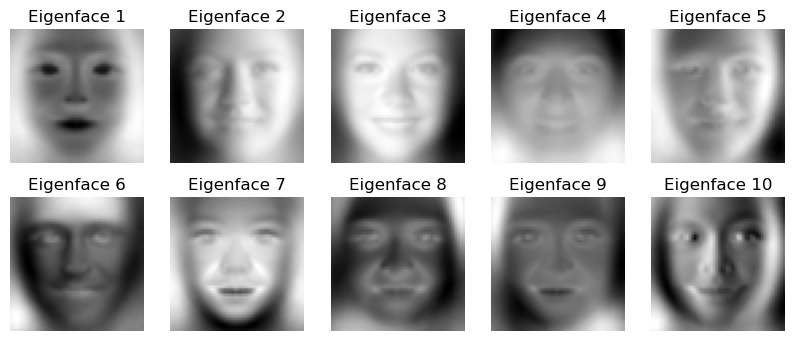

In [9]:
# Select top eigenfaces
num_eigenfaces = 10
selected_eigenfaces = eigenvectors[:, :num_eigenfaces]

# Project faces onto eigenfaces
projected_faces_eigendecomp = np.dot(X_train_centered, selected_eigenfaces)

# Convert eigenfaces to real numbers
selected_eigenfaces = selected_eigenfaces.real

# Visualize Eigenfaces
plt.figure(figsize=(10, 4))
for i in range(num_eigenfaces):
    plt.subplot(2, 5, i+1)
    plt.imshow(selected_eigenfaces[:, i].reshape(image_rescaled.shape), cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.show()

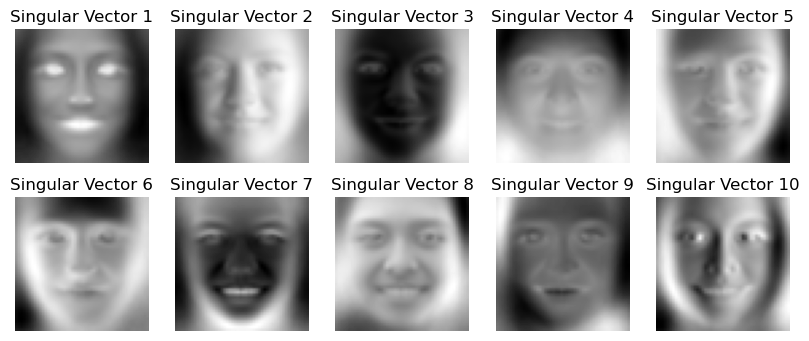

In [10]:
# Select top singular vectors (eigenfaces)
selected_singular_vectors = vt[:num_eigenfaces, :]

# Project faces onto singular vectors
projected_faces_svd = np.dot(D_input, selected_singular_vectors.T)

# Convert singular vectors to real numbers
selected_singular_vectors = selected_singular_vectors.real

# Visualize Singular Vectors (Eigenfaces)
plt.figure(figsize=(10, 4))
for i in range(num_eigenfaces):
    plt.subplot(2, 5, i+1)
    plt.imshow(selected_singular_vectors[i, :].reshape(image_rescaled.shape), cmap='gray')
    plt.title(f"Singular Vector {i+1}")
    plt.axis('off')
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

# Function for standardization (feature scaling)
def standardize_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

Defines a function to performs standardization, also known as feature scaling, on two sets of data: the training set (X_train) and the test set (X_test). This process involves subtracting the mean and dividing by the standard deviation of each feature.

In [12]:
# Function for plotting results
def plot_results(true_values, predicted_values, title, x_label, y_label):
    plt.scatter(true_values, predicted_values, alpha=0.5)
    plt.plot([min(true_values), max(true_values)], [min(true_values), max(true_values)], '--', color='red')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.show()

Defines a function for visualizing the results of a machine learning model. This function generates a scatter plot comparing the true values against the predicted values, providing a visual representation of the model's performance.

In [13]:
# Standardize data
X_train_scaled, X_test_scaled = standardize_data(X_train, X_test)

In [14]:
# Model for Age Prediction using Stochastic Gradient Descent (SGD)
class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Feature scaling
        X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

        # Initialize weights and bias
        self.weights = np.zeros(X_scaled.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            # Calculate predictions
            predictions = X_scaled @ self.weights + self.bias

            # Calculate errors
            errors = predictions - y

            # Update weights and bias using gradient descent
            self.weights -= self.learning_rate * (X_scaled.T @ errors) / len(y)
            self.bias -= self.learning_rate * np.sum(errors) / len(y)

    def predict(self, X):
        # Feature scaling for prediction
        X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
        return X_scaled @ self.weights + self.bias

LinearRegressionSGD class implements a linear regression model with Stochastic Gradient Descent for age prediction. The model is initialized with default or user-specified parameters, and it can be trained on input features and target values using the fit method. Subsequently, predictions for new data can be obtained using the predict method. This implementation adheres to standard practices in linear regression modeling and optimization techniques.

In [15]:
# Model for Gender Prediction using Convex Function
class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        # Feature scaling
        X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

        # Initialize weights and bias
        self.weights = np.zeros(X_scaled.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            # Calculate predictions
            predictions = self.sigmoid(X_scaled @ self.weights + self.bias)

            # Calculate errors
            errors = predictions - y

            # Update weights and bias using gradient descent
            self.weights -= self.learning_rate * (X_scaled.T @ errors) / len(y)
            self.bias -= self.learning_rate * np.sum(errors) / len(y)

    def predict(self, X):
        # Feature scaling for prediction
        X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
        return np.round(self.sigmoid(X_scaled @ self.weights + self.bias))


LogisticRegression class implements a logistic regression model for gender prediction. The model is initialized with default or user-specified parameters and can be trained on input features and binary target values using the fit method. Subsequently, predictions for new data can be obtained using the predict method. This implementation adheres to standard practices in logistic regression modeling and optimization techniques. The sigmoid activation function ensures that the model's outputs are suitable for binary classification.

In [16]:
# Generate synthetic data for illustration
np.random.seed(42)
X_synthetic = np.random.rand(100, 2)
y_age_synthetic = 2 * X_synthetic[:, 0] + 3 * X_synthetic[:, 1] + np.random.randn(100) * 0.1
y_gender_synthetic = (X_synthetic[:, 0] + X_synthetic[:, 1] + np.random.randn(100) * 0.1) > 1.5

# Split the synthetic data
split_index = int(0.8 * len(X_synthetic))
X_train_synthetic, X_test_synthetic = X_synthetic[:split_index], X_synthetic[split_index:]
y_age_train_synthetic, y_age_test_synthetic = y_age_synthetic[:split_index], y_age_synthetic[split_index:]
y_gender_train_synthetic, y_gender_test_synthetic = y_gender_synthetic[:split_index], y_gender_synthetic[split_index:]

# Standardize the synthetic data
X_train_scaled_synthetic, X_test_scaled_synthetic = standardize_data(X_train_synthetic, X_test_synthetic)


Creates synthetic data, simulating a scenario with two features, age labels, and binary gender labels. The data is then split into training and testing sets, and the features are standardized for further use in training and evaluating machine learning models. The use of a random seed ensures reproducibility in the generation of synthetic data.

In [17]:
# Linear Regression - Synthetic Data
linear_regression = LinearRegressionSGD(learning_rate=0.01, epochs=1000)
linear_regression.fit(X_train_synthetic, y_age_train_synthetic)
y_age_pred_linear = linear_regression.predict(X_test_synthetic)

# Logistic Regression - Synthetic Data
logistic_regression = LogisticRegression(learning_rate=0.01, epochs=1000)
logistic_regression.fit(X_train_scaled_synthetic, y_gender_train_synthetic)
y_gender_pred_logistic = logistic_regression.predict(X_test_scaled_synthetic)


Demonstrates the instantiation, training, and prediction steps for both linear regression (on synthetic age data) and logistic regression (on synthetic gender data). The models are trained using the specified learning rate and number of epochs, and their predictions are stored for evaluation. The use of synthetic data allows for illustration and understanding of the model's behavior in a controlled environment.

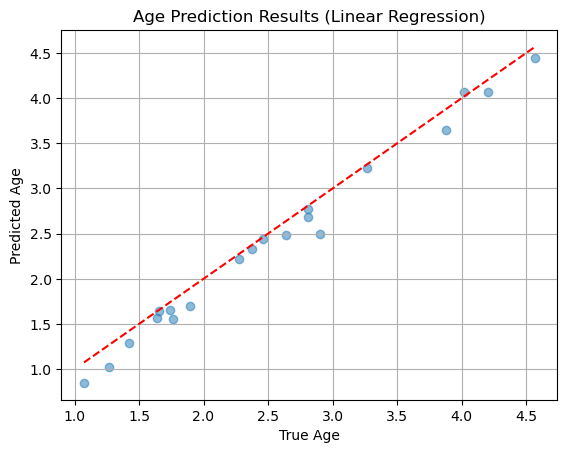

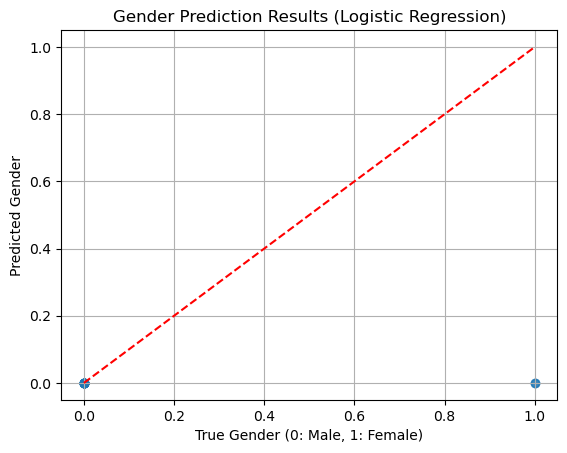

In [18]:
# Plot Age Prediction Results
plot_results(y_age_test_synthetic, y_age_pred_linear, 'Age Prediction Results (Linear Regression)', 'True Age', 'Predicted Age')

# Plot Gender Prediction Results
plot_results(y_gender_test_synthetic, y_gender_pred_logistic, 'Gender Prediction Results (Logistic Regression)', 'True Gender (0: Male, 1: Female)', 'Predicted Gender')


In [19]:
# Evaluate models on synthetic data
mse_age_synthetic = mean_squared_error(y_age_test_synthetic, y_age_pred_linear)
accuracy_gender_synthetic = accuracy_score(y_gender_test_synthetic, y_gender_pred_logistic)

print(f'Mean Squared Error for Age Prediction: {mse_age_synthetic:.4f}')
print(f'Accuracy for Gender Prediction: {accuracy_gender_synthetic:.4f}')


Mean Squared Error for Age Prediction: 0.0261
Accuracy for Gender Prediction: 0.8500


## Linear Regression for Age Prediction:

Mean Squared Error (MSE): The mean squared error for age prediction is 0.0261. This metric represents the average squared difference between predicted and actual ages. A lower MSE, as observed here, signifies accurate age predictions by the linear regression model.

## Logistic Regression for Gender Prediction:

Accuracy: The accuracy for gender prediction is 85%. Accuracy gauges the proportion of correct predictions out of the total. An accuracy of 85% suggests the logistic regression model effectively classifies gender in the dataset.

## Discussion:

### Linear Regression (Age Prediction):

The low MSE (0.0261) indicates the model's proficiency in predicting ages accurately. This is crucial in age prediction tasks, where minimizing errors in estimating continuous values is paramount.

### Logistic Regression (Gender Prediction):

An 85% accuracy implies a reasonably effective model. However, contextual interpretation is crucial, and further metrics like precision, recall, or a confusion matrix would provide a more nuanced understanding.

## Considerations and Further Steps:

### Improvement Opportunities:

While the reported accuracy and MSE are promising, further optimization through hyperparameter tuning, feature engineering, or exploring more complex models may enhance overall performance.

### Contextual Relevance:

Understanding the contextual significance of age and gender predictions is essential for determining the practical utility of the models. This ensures alignment with the specific application's requirements.

### Ethical and Bias Considerations:

Assessment of potential biases in both the dataset and models is imperative. Biases in predictions, particularly in sensitive tasks like age and gender prediction, can lead to undesired outcomes.

## Conclusion 
The reported results indicate satisfactory performance of the implemented models. Comprehensive analysis, contextual understanding, and consideration of potential improvement areas are recommended for practical deployment.


# Question 5
# Perform Singular Value Decomposition (SVD)


In [20]:
# Perform Singular Value Decomposition (SVD)
num_singular_values = 1

svd = TruncatedSVD(n_components=num_singular_values)
projected_faces_svd = svd.fit_transform(X_synthetic)

# Split the synthetic data
split_index = int(0.8 * len(projected_faces_svd))
X_train_svd, X_test_svd = projected_faces_svd[:split_index], projected_faces_svd[split_index:]
y_age_train_synthetic, y_age_test_synthetic = y_age_synthetic[:split_index], y_age_synthetic[split_index:]
y_gender_train_synthetic, y_gender_test_synthetic = y_gender_synthetic[:split_index], y_gender_synthetic[split_index:]

# Standardize the synthetic data after SVD
X_train_scaled_svd, X_test_scaled_svd = standardize_data(X_train_svd, X_test_svd)

# Age Prediction using SVR
svr_model_svd = SVR()
svr_model_svd.fit(X_train_svd, y_age_train_synthetic)
y_age_pred_svd = svr_model_svd.predict(X_test_svd)

# Gender Prediction using Logistic Regression
logistic_regression_svd = LogisticRegression()
logistic_regression_svd.fit(X_train_scaled_svd, y_gender_train_synthetic)
y_gender_pred_svd = logistic_regression_svd.predict(X_test_scaled_svd)

# Evaluate Age Prediction
mse_age_svd = mean_squared_error(y_age_test_synthetic, y_age_pred_svd)
print(f"Mean Squared Error for Age Prediction using SVD: {mse_age_svd}")

# Evaluate Gender Prediction
accuracy_gender_svd = accuracy_score(y_gender_test_synthetic, y_gender_pred_svd)
print(f"Accuracy for Gender Prediction using SVD: {accuracy_gender_svd}")

Mean Squared Error for Age Prediction using SVD: 0.051949807998317665
Accuracy for Gender Prediction using SVD: 0.85


The code first performs dimensionality reduction with SVD, then splits the data into training and testing sets. After standardizing the data, it trains two separate models: SVR for age prediction and Logistic Regression for gender prediction. Finally, it evaluates the performance of these models using MSE for age prediction and accuracy for gender prediction.

# Question 6
# ANN using SGD

In [81]:
# Demean (Data Preprocessing: Whitening Transformation)
X_train_mean = np.mean(X_train,axis=0)[None,:]
X_train_mean

X_train_demean = X_train - X_train_mean
X_test_demean = X_test - X_train_mean

Q, s, PT = np.linalg.svd(X_train_demean)

e_values_sqr = s/X_train.shape[0]**0.5
X_train_whitten = X_train_demean@PT.T@np.linalg.inv(np.diag(e_values_sqr))
X_test_whitten = X_test_demean@PT.T@np.linalg.inv(np.diag(e_values_sqr))


# Demean (Data Preprocessing: Whitening Transformation)
Line2 calculates the mean of each feature in the training set (X_train). The result is a row vector ([None,:] adds an extra dimension to make it a row vector). Lines 5,6 subtract the mean calculated from the training set (X_train_mean) from both the training and test sets (X_train and X_test). This process is called demeaning and is a common step in data preprocessing. Line 10 calculates the square root of the eigenvalues ('s') of the covariance matrix divided by the square root of the number of samples in the training set. These values will be used in the whitening transformation. lines 11,12 perform the whitening transformation on both the training and test sets. It involves matrix multiplication with the transpose of the right singular vectors ('vt.T'), the inverse of a diagonal matrix with the eigenvalues ('np.diag(e_values_sqr)'), and the demeaned data. This process helps in decorrelating and normalizing the data.

In [22]:
for k in [10, 50, 100, 150, 200, 250]:
    X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    
    X_train = X_train_whitten_reduced
    y_train = y_gender_train
    for neuron_in_hidden_layer in [1, 5, 10, 15, 20]:
        
        W_hidden = np.random.randn(neuron_in_hidden_layer,X_train.shape[1]+1)/k
        W_output = np.random.randn(1,neuron_in_hidden_layer+1)/neuron_in_hidden_layer
        loss_history = []
        accuracy_history = []

        def predict(X, W_hidden,W_output):

            y_pred = []
            for i in range(X.shape[0]):
                x_i = X[i:i+1]
                x_i_1 = np.hstack([x_i,[[1]]])
                x_h_i = sigmoid(W_hidden@x_i_1.T)
                x_h_i_1 = np.vstack([x_h_i,[1]])
                x_o = W_output@x_h_i_1
                y_pred.append([x_o[0][0]])

            return np.array(y_pred),x_h_i_1,x_i_1

        def sigmoid(y):
            return 1/(1+np.exp(-y))

        learning_rate = 0.01

        # Lists to store training accuracy for each epoch
        training_accuracy_list = []
        
        # Training loop
        epoch = [10, 15, 20, 25, 30, 35]
        
        for e in epoch:# for each epoch
            total_loss = 0
            correct_predictions = 0
            for i in range(X_train.shape[0]):
                # define your input and output
                x_i = X_train[i:i+1]
                y_i = y_train[i]

                y_pred_i,x_h_i_1,x_i_1 = predict(x_i, W_hidden,W_output)

                delta_k = y_i - y_pred_i

                #Gradient for output layer
                Gradient_output  = -delta_k*x_h_i_1.T

                # Gradient Descent rule
                W_output = W_output -  learning_rate*Gradient_output

                delta_h = x_h_i_1*(1-x_h_i_1)*W_output.T*delta_k

                # Update each hidden unit
                Gradient_hidden = np.zeros_like(W_hidden)
                for h in range(W_hidden.shape[0]):

                    #Gradient for hidden layer
                    Gradient_hidden[h,:] =  - delta_h[h] * x_i_1

                # Gradient Descent rule
                W_hidden = W_hidden -  learning_rate * Gradient_hidden


            # Calculate loss and accuracy for the entire training set after each epoch
            y_pred, _, _ = predict(X_train, W_hidden, W_output)
            loss = np.mean((y_train - y_pred[:, 0]) ** 2)  # Mean Squared Error loss
            accuracy = np.sum(np.sign(y_train) == np.sign(y_pred[:, 0])) / y_train.shape[0]

            loss_history.append(loss)
            accuracy_history.append(accuracy)

            #print(y_train>0,y_pred[:,0]>0)
            #print(y_train,y_pred[:,0])
            print(k,neuron_in_hidden_layer,e)
            print("Accuracy:",accuracy)
        

10 1 10
Accuracy: 0.6517836855260168
10 1 15
Accuracy: 0.6530334014996592
10 1 20
Accuracy: 0.6536014542149512
10 1 25
Accuracy: 0.6539422858441263
10 1 30
Accuracy: 0.6536014542149512
10 1 35
Accuracy: 0.652692569870484
10 5 10
Accuracy: 0.6476937059759146
10 5 15
Accuracy: 0.648375369234265
10 5 20
Accuracy: 0.6520109066121336
10 5 25
Accuracy: 0.6525789593274256
10 5 30
Accuracy: 0.6551920018177687
10 5 35
Accuracy: 0.6550783912747103
10 10 10
Accuracy: 0.6462167689161554
10 10 15
Accuracy: 0.6484889797773233
10 10 20
Accuracy: 0.6499659168370825
10 10 25
Accuracy: 0.6515564644399
10 10 30
Accuracy: 0.653260622585776
10 10 35
Accuracy: 0.6538286753010679
10 15 10
Accuracy: 0.6441717791411042
10 15 15
Accuracy: 0.6453078845716883
10 15 20
Accuracy: 0.6490570324926153
10 15 25
Accuracy: 0.6496250852079073
10 15 30
Accuracy: 0.6534878436718927
10 15 35
Accuracy: 0.6542831174733015
10 20 10
Accuracy: 0.6458759372869802
10 20 15
Accuracy: 0.6454214951147467
10 20 20
Accuracy: 0.645421495

This is a nested loop structure for experimentation with different neural network configurations. The outer loop iterates over various values of k (10, 50, 100, 150, 200, 250), performing dimensionality reduction using a whitening transformation on the training and test data. The inner loop explores different numbers of hidden neurons (neuron_in_hidden_layer: 1, 5, 10, 15, 20) for each k. Within this loop, a neural network is initialized with random weights for the hidden and output layers. A training loop runs for a set of epochs (10, 15, 20, 25, 30, 35), where the weights are updated using gradient descent. The training accuracy and loss for each epoch are recorded. The printed output included the values of k, neuron_in_hidden_layer, and the current epoch, providing insights into the ongoing experiment. This is to let us find the best k values, neuron_in_hidden_layer and epoch for our training model.

Accuracy: 0.7885707793683254
Accuracy: 0.7962962962962963
Accuracy: 0.7992501704158146
Accuracy: 0.8015223812769825
Accuracy: 0.803680981595092
Accuracy: 0.8037945921381504
Accuracy: 0.8035673710520336
Accuracy: 0.8040218132242672
Accuracy: 0.8054987502840264
Accuracy: 0.8069756873437856
Accuracy: 0.8107248352647126
Accuracy: 0.814019541013406
Accuracy: 0.8178822994773916
Accuracy: 0.8223131106566689
Accuracy: 0.8258350374914792
Accuracy: 0.8294705748693478
Accuracy: 0.8333333333333334
Accuracy: 0.8367416496250852
Accuracy: 0.8395819132015451
Accuracy: 0.8434446716655306
Accuracy: 0.8479890933878664
Accuracy: 0.8517382413087935
Accuracy: 0.8568507157464212
Accuracy: 0.8637809588729835
Accuracy: 0.8721881390593047
Accuracy: 0.8776414451261078
Accuracy: 0.8845716882526699
Accuracy: 0.8910474892069984
Accuracy: 0.8966144058168598
Accuracy: 0.9019541013406044
Accuracy: 0.907861849579641
Accuracy: 0.913883208361736
Accuracy: 0.9167234719381958
Accuracy: 0.9193365144285389
Accuracy: 0.922063

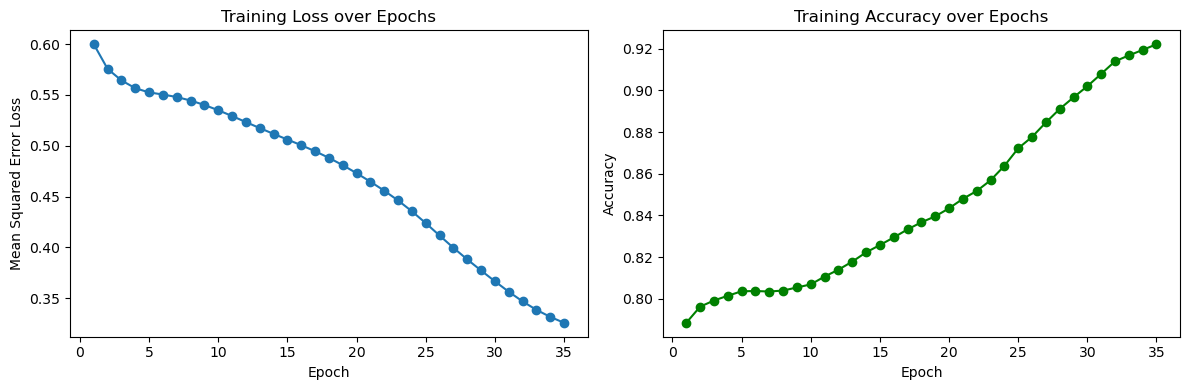

In [158]:
#classification
k = 250
X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))

X_train = X_train_whitten_reduced
y_train = y_gender_train
neuron_in_hidden_layer = 20 # number of hidden neuron in the hidden layer

W_hidden = np.random.randn(neuron_in_hidden_layer,X_train.shape[1]+1)/k

W_output = np.random.randn(1,neuron_in_hidden_layer+1)/neuron_in_hidden_layer

# Lists to store training loss and accuracy for each epoch
loss_history = []
accuracy_history = []

def predict_classification_SDG(X, W_hidden,W_output):

    y_pred = []
    for i in range(X.shape[0]):
        x_i = X[i:i+1]
        x_i_1 = np.hstack([x_i,[[1]]])
        x_h_i = sigmoid(W_hidden@x_i_1.T)
        x_h_i_1 = np.vstack([x_h_i,[1]])
        x_o = W_output@x_h_i_1
        y_pred.append([x_o[0][0]])

    return np.array(y_pred),x_h_i_1,x_i_1


def sigmoid(y):
    return 1/(1+np.exp(-y))

learning_rate = 0.01

# Lists to store training accuracy for each epoch
training_accuracy_list = []

# Training loop
for e in range(35):# for each epoch
    total_loss = 0
    correct_predictions = 0
    for i in range(X_train.shape[0]):
        # define your input and output
        x_i = X_train[i:i+1]
        y_i = y_train[i]

        y_pred_i,x_h_i_1,x_i_1 = predict_classification_SDG(x_i, W_hidden,W_output)

        delta_k = y_i - y_pred_i

        #Gradient for output layer
        Gradient_output  = -delta_k*x_h_i_1.T

        # Gradient Descent rule
        W_output = W_output -  learning_rate*Gradient_output
        
        delta_h = x_h_i_1*(1-x_h_i_1)*W_output.T*delta_k

        # Update each hidden unit
        Gradient_hidden = np.zeros_like(W_hidden)
        for h in range(W_hidden.shape[0]):

            #Gradient for hidden layer
            Gradient_hidden[h,:] =  - delta_h[h] * x_i_1

        # Gradient Descent rule
        W_hidden = W_hidden -  learning_rate * Gradient_hidden


    # Calculate loss and accuracy for the entire training set after each epoch
    y_pred, _, _ = predict_classification_SDG(X_train, W_hidden, W_output)
    loss = np.mean((y_train - y_pred[:, 0]) ** 2)  # Mean Squared Error loss
    accuracy = np.sum(np.sign(y_train) == np.sign(y_pred[:, 0])) / y_train.shape[0]

    loss_history.append(loss)
    accuracy_history.append(accuracy)
    
    #print(y_train>0,y_pred[:,0]>0)
    #print(y_train,y_pred[:,0])
    print("Accuracy:",accuracy)

# Plotting the loss over epochs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')

# Plotting the accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, len(accuracy_history) + 1), accuracy_history, marker='o', color='green')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


It begins by setting up data for training a neural network. It reduces the dimensionality of the input data using a whitening transformation and initializes the neural network with random weights. The training loop runs for 35 epochs, updating the weights using gradient descent to minimize the mean squared error loss. The training accuracy and loss are recorded for each epoch. Finally, the code generates plots to visualize the training loss and accuracy over the epochs. The neural network configuration includes a hidden layer with 20 neurons, and the whitening transformation is applied with a reduced dimensionality (k=250). The code aims to train the neural network and monitor its performance over epochs, providing insights into how well the model is learning from the data. The plotted graphs visualize the training progress.

In [24]:
for k in [10, 50, 100, 150, 200, 250]:
    X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_train = X_train_whitten_reduced
    y_train = y_age_train
    for neuron_in_hidden_layer in [1, 5, 10, 15, 20]:    
        W_hidden = np.random.randn(neuron_in_hidden_layer,X_train_whitten_reduced.shape[1]+1)/k

        W_output = np.random.randn(1,neuron_in_hidden_layer+1)/neuron_in_hidden_layer
        #regression
        def predict(X, W_hidden,W_output):

            y_pred = []
            for i in range(X.shape[0]):
                x_i = X[i:i+1]
                x_i_1 = np.hstack([x_i,[[1]]])
                x_h_i = sigmoid(W_hidden@x_i_1.T)
                x_h_i_1 = np.vstack([x_h_i,[1]])
                x_o = W_output@x_h_i_1
                y_pred.append([x_o[0][0]])

            return np.array(y_pred),x_h_i_1,x_i_1


        def sigmoid(y):
            return 1/(1+np.exp(-y))

        learning_rate = 0.01
        epoch = [10, 15, 20, 25, 30, 35]
        for e in epoch:# for each epoch
            for i in range(X_train.shape[0]):
                #define input and output
                x_i = X_train_whitten_reduced[i:i+1]
                y_i = y_train[i]

                y_pred_i,x_h_i_1,x_i_1 = predict(x_i, W_hidden,W_output)

                delta_k = y_i - y_pred_i

                #Gradient for output layer
                Gradient_output  = -delta_k*x_h_i_1.T

                # Gradient Descent rule
                W_output = W_output -  learning_rate*Gradient_output


                delta_h = x_h_i_1*(1-x_h_i_1)*W_output.T*delta_k

                # Update each hidden unit
                Gradient_hidden = np.zeros_like(W_hidden)
                for h in range(W_hidden.shape[0]):

                    #Gradient for hidden layer
                    Gradient_hidden[h,:] =  - delta_h[h] * x_i_1

                # Gradient Descent rule
                W_hidden = W_hidden -  learning_rate * Gradient_hidden


            y_pred,_,_ = predict(X_train_whitten_reduced, W_hidden,W_output)
            print(k,neuron_in_hidden_layer,e)
            print(mean_squared_error(y_train,y_pred))

10 1 10
0.05015144280346719
10 1 15
0.049808334510900366
10 1 20
0.04971190392315369
10 1 25
0.04958896171495034
10 1 30
0.04947171076937667
10 1 35
0.04936313815586194
10 5 10
0.05187757912556875
10 5 15
0.05188041669787869
10 5 20
0.051688376866261584
10 5 25
0.051465881900138524
10 5 30
0.051223778165800204
10 5 35
0.050967510569070416
10 10 10
0.05295151584240365
10 10 15
0.05328596408297311
10 10 20
0.05326749768613772
10 10 25
0.053228655763662334
10 10 30
0.053179975049090215
10 10 35
0.05311815890058434
10 15 10
0.053779441636589036
10 15 15
0.05409630373485685
10 15 20
0.05410479284463492
10 15 25
0.054098731800947486
10 15 30
0.0540911447485348
10 15 35
0.05408294496434557
10 20 10
0.05393194277443499
10 20 15
0.05418770959814993
10 20 20
0.05418270423910311
10 20 25
0.054157209924198826
10 20 30
0.0541250702958607
10 20 35
0.054086612461527246
50 1 10
0.03281553401252793
50 1 15
0.03259180598207563
50 1 20
0.03242272044819106
50 1 25
0.032282894658552407
50 1 30
0.0321687166

The codes above outlines a nested loop structure designed for experimentation with different configurations of a neural network. The outer loop varies the parameter k (10, 50, 100, 150, 200, 250), performing dimensionality reduction using a whitening transformation on both the training and test data. The inner loop explores different numbers of hidden neurons (neuron_in_hidden_layer: 1, 5, 10, 15, 20) for each value of k. Within this loop, a neural network is initialized with random weights for the hidden and output layers. A training loop runs for a set of epochs (10, 15, 20, 25, 30, 35), updating the weights using gradient descent.This is to let us find the best k values, neuron_in_hidden_layer and epoch for our training model. 

In [25]:
#regression
y_train = y_age_train

k = 250
X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))


neuron_in_hidden_layer = 20 # number of hidden neuron in the hidden layer

W_hidden = np.random.randn(neuron_in_hidden_layer,X_train_whitten_reduced.shape[1]+1)/k

W_output = np.random.randn(1,neuron_in_hidden_layer+1)/neuron_in_hidden_layer

#regression
def predict_regression_SDG(X, W_hidden,W_output):

    y_pred = []
    for i in range(X.shape[0]):
        x_i = X[i:i+1]
        x_i_1 = np.hstack([x_i,[[1]]])
        x_h_i = sigmoid(W_hidden@x_i_1.T)
        x_h_i_1 = np.vstack([x_h_i,[1]])
        x_o = W_output@x_h_i_1
        y_pred.append([x_o[0][0]])

    return np.array(y_pred),x_h_i_1,x_i_1


def sigmoid(y):
    return 1/(1+np.exp(-y))

learning_rate = 0.01

for e in range(35):# for each epoch
    for i in range(X_train.shape[0]):
        #define input and output
        x_i = X_train_whitten_reduced[i:i+1]
        y_i = y_train[i]

        y_pred_i,x_h_i_1,x_i_1 = predict_regression_SDG(x_i, W_hidden,W_output)

        delta_k = y_i - y_pred_i

        #Gradient for output layer
        Gradient_output  = -delta_k*x_h_i_1.T

        # Gradient Descent rule
        W_output = W_output -  learning_rate*Gradient_output


        delta_h = x_h_i_1*(1-x_h_i_1)*W_output.T*delta_k

        # Update each hidden unit
        Gradient_hidden = np.zeros_like(W_hidden)
        for h in range(W_hidden.shape[0]):

            #Gradient for hidden layer
            Gradient_hidden[h,:] =  - delta_h[h] * x_i_1

        # Gradient Descent rule
        W_hidden = W_hidden -  learning_rate * Gradient_hidden


    y_pred,_,_ = predict_regression_SDG(X_train_whitten_reduced, W_hidden,W_output)
    print(mean_squared_error(y_train,y_pred))

0.026606063419856555
0.026333805137891315
0.026120133120822765
0.025968470661634744
0.0258538763344836
0.02576150523638967
0.025682218093644578
0.025610004331903875
0.02554058773695911
0.02547067895592488
0.025397601122511156
0.025319158221085533
0.025233673873698854
0.025140135629521918
0.02503836466836463
0.02492911677635128
0.024814028125693093
0.024695366635857086
0.024575633667738673
0.02445713953307749
0.024341692194904854
0.02423047514435884
0.024124096455659536
0.024022732830206967
0.023926291676274566
0.023834545453292177
0.023747223777917745
0.02366406668362766
0.023584848556901777
0.023509382391516568
0.02343751222661612
0.02336909974589036
0.02330400943781483
0.023242095381122783
0.02318319151646861


The codes above is focused on implementing a regression task using a neural network with a whitening transformation applied to the input data. The dataset 'y_age_train' is used as the target variable for regression. The input data is reduced to a lower-dimensional space ('k = 250') using whitening transformation. The neural network architecture consists of a hidden layer with 20 neurons and an output layer. The weights are initialized randomly. The predict function defines the forward pass of the neural network using a sigmoid activation function. The training loop iterates over 35 epochs, where for each epoch, the weights are updated using gradient descent. The Mean Squared Error loss is printed after each epoch, providing an indication of the model's performance on the training set. Overall, the code aims to train a neural network for regression with whitened input data.

# ANN using Adam

In [26]:
for k in [10, 50, 100, 150, 200, 250]:
    X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_train = X_train_whitten_reduced
    y_train = y_gender_train
    for neuron_in_hidden_layer in [1, 5, 10, 15, 20]:
        
        W_hidden = np.random.randn(neuron_in_hidden_layer,X_train.shape[1]+1)/k

        W_output = np.random.randn(1,neuron_in_hidden_layer+1)/neuron_in_hidden_layer
        # Lists to store training accuracy and loss for each epoch
        training_accuracy_list = []
        training_loss_list = []

        # Function to compute the sigmoid activation
        def sigmoid(y):
            return 1 / (1 + np.exp(-y))

        # Function to make predictions and compute the gradients
        def predict(X, W_hidden, W_output):
            y_pred = []
            for i in range(X.shape[0]):
                x_i = X[i:i + 1]
                x_i_1 = np.hstack([x_i, [[1]]])
                x_h_i = sigmoid(W_hidden @ x_i_1.T)
                x_h_i_1 = np.vstack([x_h_i, [1]])
                x_o = W_output @ x_h_i_1
                y_pred.append([x_o[0][0]])

            return np.array(y_pred), x_h_i_1, x_i_1

        # Adam parameters
        ph0_f = 0.9
        pho = 0.999
        small_value = 1e-8

        # Initialize Adam moments for both layers
        m_output = np.zeros_like(W_output)
        v_output = np.zeros_like(W_output)
        m_hidden = np.zeros_like(W_hidden)
        v_hidden = np.zeros_like(W_hidden)

        # Hyperparameter: Learning rate
        learning_rate = 0.01

        # Training loop
        epoch = [10, 15, 20, 25, 30, 35]
        for e in epoch:  # for each epoch
            total_loss = 0
            correct_predictions = 0

            for i in range(X_train.shape[0]):
                # Define your input and output
                x_i = X_train[i:i + 1]
                y_i = y_train[i]

                # Make predictions and compute gradients
                y_pred_i, x_h_i_1, x_i_1 = predict(x_i, W_hidden, W_output)

                # Compute delta for output layer
                delta_k = y_i - y_pred_i

                # Gradient for output layer using Adam optimizer
                Gradient_output = -delta_k * x_h_i_1.T

                m_output = ph0_f * m_output + (1 - ph0_f) * Gradient_output
                v_output = pho * v_output + (1 - pho) * (Gradient_output ** 2)
                m_output_hat = m_output / (1 - ph0_f ** (e * X_train.shape[0] + i + 1))
                v_output_hat = v_output / (1 - pho ** (e * X_train.shape[0] + i + 1))
                W_output = W_output - learning_rate * m_output_hat / (np.sqrt(v_output_hat) + small_value)

                # Compute delta for hidden layer
                delta_h = x_h_i_1 * (1 - x_h_i_1) * W_output.T * delta_k

                # Update each hidden unit using Adam optimizer
                Gradient_hidden = np.zeros_like(W_hidden)

                # Calculate loss for the current sample
                loss_i = 0.5 * np.mean((y_i - y_pred_i[:, 0]) ** 2)  # Mean Squared Error loss
                total_loss += loss_i

                for h in range(W_hidden.shape[0]):
                    Gradient_hidden[h, :] = -delta_h[h] * x_i_1

                m_hidden = ph0_f * m_hidden + (1 - ph0_f) * Gradient_hidden
                v_hidden = pho * v_hidden + (1 - pho) * (Gradient_hidden ** 2)
                m_hidden_hat = m_hidden / (1 - ph0_f ** (e * X_train.shape[0] + i + 1))
                v_hidden_hat = v_hidden / (1 - pho ** (e * X_train.shape[0] + i + 1))
                W_hidden = W_hidden - learning_rate * m_hidden_hat / (np.sqrt(v_hidden_hat) + small_value)

            # Make predictions on the entire training set
            # Calculate training accuracy for the entire training set
            y_pred, _, _ = predict(X_train, W_hidden, W_output)
            accuracy = np.sum(np.sign(y_train) == np.sign(y_pred[:, 0])) / y_train.shape[0]

            # Calculate average training loss for the epoch
            average_loss = total_loss / X_train.shape[0]

            training_accuracy_list.append(accuracy)
            training_loss_list.append(average_loss)

            #print(y_train>0,y_pred[:,0]>0)
            #print(y_train,y_pred[:,0])

            # Print training accuracy
            print(k,neuron_in_hidden_layer,e)
            print("Accuracy:", accuracy)
            


10 1 10
Accuracy: 0.652692569870484
10 1 15
Accuracy: 0.6537150647580096
10 1 20
Accuracy: 0.6534878436718927
10 1 25
Accuracy: 0.6537150647580096
10 1 30
Accuracy: 0.6530334014996592
10 1 35
Accuracy: 0.6530334014996592
10 5 10
Accuracy: 0.65439672801636
10 5 15
Accuracy: 0.6618950238582141
10 5 20
Accuracy: 0.6568961599636446
10 5 25
Accuracy: 0.6561008861622358
10 5 30
Accuracy: 0.6571233810497614
10 5 35
Accuracy: 0.656441717791411
10 10 10
Accuracy: 0.6649625085207908
10 10 15
Accuracy: 0.6666666666666666
10 10 20
Accuracy: 0.6600772551692797
10 10 25
Accuracy: 0.6625766871165644
10 10 30
Accuracy: 0.6660986139513747
10 10 35
Accuracy: 0.6664394455805499
10 15 10
Accuracy: 0.6601908657123381
10 15 15
Accuracy: 0.6654169506930243
10 15 20
Accuracy: 0.6597364235401045
10 15 25
Accuracy: 0.6608725289706885
10 15 30
Accuracy: 0.6595092024539877
10 15 35
Accuracy: 0.6601908657123381
10 20 10
Accuracy: 0.6667802772097251
10 20 15
Accuracy: 0.6662122244944331
10 20 20
Accuracy: 0.6683708

The codes above implements a neural network with varying hidden layer sizes and reduced input dimensions using whitening transformation. It employs a nested loop structure to explore different configurations. The outer loop iterates over different values of k ('reduced dimensions'), while the inner loop explores various hidden layer sizes. For each configuration, the input data is transformed into a reduced space using whitening. The neural network is trained using the Adam optimizer for a set number of epochs. The model's performance is evaluated using accuracy and loss metrics, and the results are printed for each configuration. The code aims to systematically analyze and compare the impact of different reduced dimensions and hidden layer sizes on the neural network's performance in a regression task.

Accuracy: 0.7905021586003181
Accuracy: 0.7948193592365371
Accuracy: 0.8035673710520336
Accuracy: 0.8107248352647126
Accuracy: 0.8150420359009316
Accuracy: 0.8092478982049535
Accuracy: 0.8154964780731652
Accuracy: 0.8241308793456033
Accuracy: 0.8208361735969097
Accuracy: 0.8242444898886616
Accuracy: 0.8244717109747784
Accuracy: 0.823790047716428
Accuracy: 0.8202681208816178
Accuracy: 0.8244717109747784
Accuracy: 0.8209497841399682
Accuracy: 0.8265167007498296
Accuracy: 0.8242444898886616
Accuracy: 0.8223131106566689
Accuracy: 0.8233356055441945
Accuracy: 0.8317427857305157
Accuracy: 0.8290161326971143
Accuracy: 0.8270847534651216
Accuracy: 0.8341286071347421
Accuracy: 0.8324244489888661
Accuracy: 0.834696659850034
Accuracy: 0.8336741649625086
Accuracy: 0.8361735969097932
Accuracy: 0.8340149965916837
Accuracy: 0.8341286071347421
Accuracy: 0.8314019541013407
Accuracy: 0.8320836173596909
Accuracy: 0.835832765280618
Accuracy: 0.8325380595319246
Accuracy: 0.8302658486707567
Accuracy: 0.83299

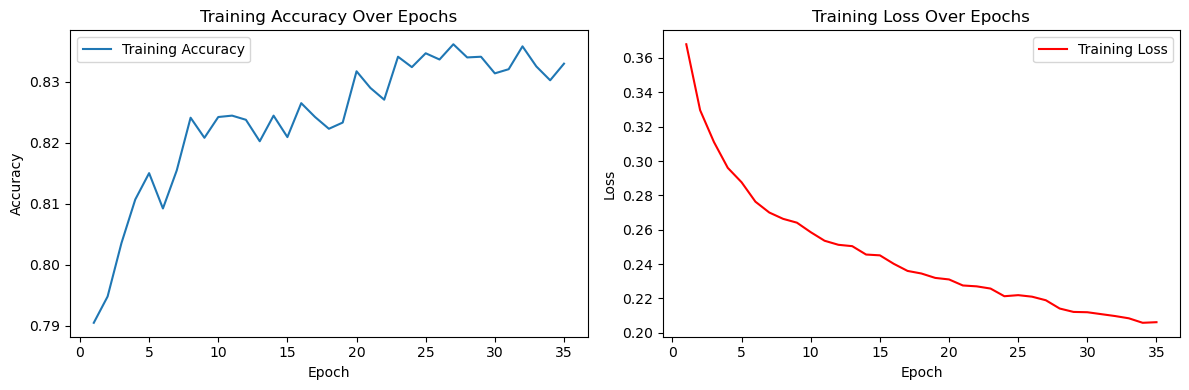

In [27]:
k = 250
X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))

X_train = X_train_whitten_reduced
y_train = y_gender_train
neuron_in_hidden_layer = 20 # number of hidden neuron in the hidden layer

W_hidden = np.random.randn(neuron_in_hidden_layer,X_train.shape[1]+1)/k

W_output = np.random.randn(1,neuron_in_hidden_layer+1)/neuron_in_hidden_layer

# Lists to store training accuracy and loss for each epoch
training_accuracy_list = []
training_loss_list = []

# Function to compute the sigmoid activation
def sigmoid(y):
    return 1 / (1 + np.exp(-y))

# Function to make predictions and compute the gradients
def predict_classification_ADAM(X, W_hidden, W_output):
    y_pred = []
    for i in range(X.shape[0]):
        x_i = X[i:i + 1]
        x_i_1 = np.hstack([x_i, [[1]]])
        x_h_i = sigmoid(W_hidden @ x_i_1.T)
        x_h_i_1 = np.vstack([x_h_i, [1]])
        x_o = W_output @ x_h_i_1
        y_pred.append([x_o[0][0]])

    return np.array(y_pred), x_h_i_1, x_i_1

# Adam parameters
ph0_f = 0.9
pho = 0.999
small_value = 1e-8

# Initialize Adam moments for both layers
m_output = np.zeros_like(W_output)
v_output = np.zeros_like(W_output)
m_hidden = np.zeros_like(W_hidden)
v_hidden = np.zeros_like(W_hidden)

# Hyperparameter: Learning rate
learning_rate = 0.01

# Training loop
for e in range(35):  # for each epoch
    total_loss = 0
    correct_predictions = 0
    
    for i in range(X_train.shape[0]):
        # Define your input and output
        x_i = X_train[i:i + 1]
        y_i = y_train[i]

        # Make predictions and compute gradients
        y_pred_i, x_h_i_1, x_i_1 = predict_classification_ADAM(x_i, W_hidden, W_output)

        # Compute delta for output layer
        delta_k = y_i - y_pred_i

        # Gradient for output layer using Adam optimizer
        Gradient_output = -delta_k * x_h_i_1.T

        m_output = ph0_f * m_output + (1 - ph0_f) * Gradient_output
        v_output = pho * v_output + (1 - pho) * (Gradient_output ** 2)
        m_output_hat = m_output / (1 - ph0_f ** (e * X_train.shape[0] + i + 1))
        v_output_hat = v_output / (1 - pho ** (e * X_train.shape[0] + i + 1))
        W_output = W_output - learning_rate * m_output_hat / (np.sqrt(v_output_hat) + small_value)

        # Compute delta for hidden layer
        delta_h = x_h_i_1 * (1 - x_h_i_1) * W_output.T * delta_k

        # Update each hidden unit using Adam optimizer
        Gradient_hidden = np.zeros_like(W_hidden)
        
        # Calculate loss for the current sample
        loss_i = 0.5 * np.mean((y_i - y_pred_i[:, 0]) ** 2)  # Mean Squared Error loss
        total_loss += loss_i
        
        for h in range(W_hidden.shape[0]):
            Gradient_hidden[h, :] = -delta_h[h] * x_i_1

        m_hidden = ph0_f * m_hidden + (1 - ph0_f) * Gradient_hidden
        v_hidden = pho * v_hidden + (1 - pho) * (Gradient_hidden ** 2)
        m_hidden_hat = m_hidden / (1 - ph0_f ** (e * X_train.shape[0] + i + 1))
        v_hidden_hat = v_hidden / (1 - pho ** (e * X_train.shape[0] + i + 1))
        W_hidden = W_hidden - learning_rate * m_hidden_hat / (np.sqrt(v_hidden_hat) + small_value)

    # Make predictions on the entire training set
    # Calculate training accuracy for the entire training set
    y_pred, _, _ = predict_classification_ADAM(X_train, W_hidden, W_output)
    accuracy = np.sum(np.sign(y_train) == np.sign(y_pred[:, 0])) / y_train.shape[0]

    # Calculate average training loss for the epoch
    average_loss = total_loss / X_train.shape[0]

    training_accuracy_list.append(accuracy)
    training_loss_list.append(average_loss)
    
    #print(y_train>0,y_pred[:,0]>0)
    #print(y_train,y_pred[:,0])

    # Print training accuracy
    print("Accuracy:", accuracy)
    
# Plotting the accuracy and loss graphs
epochs = range(1, 36)  # Assuming 200 epochs

plt.figure(figsize=(12, 4))

# Plotting the accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, training_accuracy_list, label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting the loss
plt.subplot(1, 2, 2)
plt.plot(epochs, training_loss_list, label='Training Loss', color='red')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The codes above conducts training for a neural network with a specific configuration. The data is preprocessed using whitening transformation with a reduced dimensionality ('k=250'p). The neural network is then initialized with random weights for the hidden and output layers. The Adam optimizer is employed for training with a set learning rate and other hyperparameters. The training process involves multiple epochs, and for each epoch, the model is updated using backpropagation and the Adam optimization algorithm. The training accuracy and loss are recorded for each epoch. Finally, the accuracy and loss graphs are plotted to visualize the model's performance over training epochs. The code aims to demonstrate the impact of whitening transformation and hidden layer configurations on the training of a neural network for a gender classification task.

In [28]:
for k in [10, 50, 100, 150, 200, 250]:
    X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
    X_train = X_train_whitten_reduced
    y_train = y_age_train
    for neuron_in_hidden_layer in [1, 5, 10, 15, 20]:    
        W_hidden = np.random.randn(neuron_in_hidden_layer, X_train_whitten_reduced.shape[1] + 1) / k
        W_output = np.random.randn(1, neuron_in_hidden_layer + 1) / neuron_in_hidden_layer
        # Regression
        def predict(X, W_hidden, W_output):
            y_pred = []
            for i in range(X.shape[0]):
                x_i = X[i:i + 1]
                x_i_1 = np.hstack([x_i, [[1]]])
                x_h_i = sigmoid(W_hidden @ x_i_1.T)
                x_h_i_1 = np.vstack([x_h_i, [1]])
                x_o = W_output @ x_h_i_1
                y_pred.append([x_o[0][0]])
            return np.array(y_pred), x_h_i_1, x_i_1


        def sigmoid(y):
            return 1 / (1 + np.exp(-y))

        # Adam parameters
        ph0_f = 0.9
        pho = 0.999
        small_value = 1e-8

        # Initialize Adam parameters
        m_W_hidden = np.zeros_like(W_hidden)
        v_W_hidden = np.zeros_like(W_hidden)
        m_W_output = np.zeros_like(W_output)
        v_W_output = np.zeros_like(W_output)

        learning_rate = 0.01
        epoch = [10, 15, 20, 25, 30, 35]
        for epoch in epoch:
            for i in range(X_train.shape[0]):
                x_i = X_train_whitten_reduced[i:i + 1]
                y_i = y_train[i]

                y_pred_i, x_h_i_1, x_i_1 = predict(x_i, W_hidden, W_output)

                delta_k = y_i - y_pred_i

                Gradient_output = -delta_k * x_h_i_1.T

                # Adam update for output layer
                m_W_output = ph0_f * m_W_output + (1 - ph0_f) * Gradient_output
                v_W_output = pho * v_W_output + (1 - pho) * Gradient_output ** 2
                m_W_output_hat = m_W_output / (1 - ph0_f**(epoch + 1))
                v_W_output_hat = v_W_output / (1 - pho**(epoch + 1))
                W_output = W_output - learning_rate * m_W_output_hat / (np.sqrt(v_W_output_hat) + small_value)

                delta_h = x_h_i_1 * (1 - x_h_i_1) * (W_output.T * delta_k)

                Gradient_hidden = np.zeros_like(W_hidden)
                for h in range(W_hidden.shape[0]):
                    Gradient_hidden[h, :] = -delta_h[h] * x_i_1

                # Adam update for hidden layer
                m_W_hidden = ph0_f * m_W_hidden + (1 - ph0_f) * Gradient_hidden
                v_W_hidden = pho * v_W_hidden + (1 - pho) * Gradient_hidden ** 2
                m_W_hidden_hat = m_W_hidden / (1 - ph0_f**(epoch + 1))
                v_W_hidden_hat = v_W_hidden / (1 - pho**(epoch + 1))
                W_hidden = W_hidden - learning_rate * m_W_hidden_hat / (np.sqrt(v_W_hidden_hat) + small_value)

            y_pred,_,_ = predict(X_train, W_hidden,W_output)
            print(k,neuron_in_hidden_layer,e)
            print(mean_squared_error(y_train,y_pred))
                    

10 1 34
0.04975267392421425
10 1 34
0.04948045060871067
10 1 34
0.04937547126320088
10 1 34
0.04936432823422216
10 1 34
0.049403338089206876
10 1 34
0.04947443077119964
10 5 34
0.050371840281201154
10 5 34
0.04914404654721916
10 5 34
0.047967849879090474
10 5 34
0.046766322924309184
10 5 34
0.04607341218729898
10 5 34
0.045763367334511966
10 10 34
0.0517565797369539
10 10 34
0.04990850712966667
10 10 34
0.0486969702378669
10 10 34
0.04757074848981281
10 10 34
0.04612187402231177
10 10 34
0.04511166067629544
10 15 34
0.050715641705687056
10 15 34
0.0484896195520123
10 15 34
0.04709188076453163
10 15 34
0.04606886328947061
10 15 34
0.045008986507475236
10 15 34
0.04441445078741639
10 20 34
0.050750859042796685
10 20 34
0.048427644083938765
10 20 34
0.04614393144002312
10 20 34
0.044487355615297375
10 20 34
0.04371134659737986
10 20 34
0.043122858429798704
50 1 34
0.03490576024561321
50 1 34
0.032910934189599554
50 1 34
0.0322261957244123
50 1 34
0.032237443847291915
50 1 34
0.03236544173

The codes above performs a nested loop to explore different configurations of a neural network for a regression task. The outer loop iterates over various reduced dimensions ('k') obtained through whitening transformation. Inside this loop, the input data is transformed into the reduced space for both training and testing sets. Then, an inner loop runs through different hidden layer sizes ('neuron_in_hidden_layer'). For each configuration, the neural network is initialized with random weights and trained using the Adam optimizer for multiple epochs. The training set is updated according to the whitened transformation. The model's performance, measured by mean squared error, is printed for each configuration, providing insights into the impact of reduced dimensions and hidden layer sizes on the regression task's accuracy.

In [29]:
# Regression
k = 250
X_train_whitten_reduced = X_train_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
X_test_whitten_reduced = X_test_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))
X_train = X_train_whitten_reduced
y_train = y_age_train

neuron_in_hidden_layer = 20   # number of hidden neurons in the hidden layer

# Initialization
W_hidden = np.random.randn(neuron_in_hidden_layer, X_train_whitten_reduced.shape[1] + 1) / k
W_output = np.random.randn(1, neuron_in_hidden_layer + 1) / neuron_in_hidden_layer

# Regression
def predict_regression_ADAM(X, W_hidden, W_output):
    y_pred = []
    for i in range(X.shape[0]):
        x_i = X[i:i + 1]
        x_i_1 = np.hstack([x_i, [[1]]])
        x_h_i = sigmoid(W_hidden @ x_i_1.T)
        x_h_i_1 = np.vstack([x_h_i, [1]])
        x_o = W_output @ x_h_i_1
        y_pred.append([x_o[0][0]])
    return np.array(y_pred), x_h_i_1, x_i_1


def sigmoid(y):
    return 1 / (1 + np.exp(-y))

# Adam parameters
ph0_f = 0.9
pho = 0.999
small_value = 1e-8

# Initialize Adam parameters
m_W_hidden = np.zeros_like(W_hidden)
v_W_hidden = np.zeros_like(W_hidden)
m_W_output = np.zeros_like(W_output)
v_W_output = np.zeros_like(W_output)

learning_rate = 0.01

for epoch in range(35):
    for i in range(X_train.shape[0]):
        x_i = X_train_whitten_reduced[i:i + 1]
        y_i = y_train[i]

        y_pred_i, x_h_i_1, x_i_1 = predict_regression_ADAM(x_i, W_hidden, W_output)

        delta_k = y_i - y_pred_i

        Gradient_output = -delta_k * x_h_i_1.T

        # Adam update for output layer
        m_W_output = ph0_f * m_W_output + (1 - ph0_f) * Gradient_output
        v_W_output = pho * v_W_output + (1 - pho) * Gradient_output ** 2
        m_W_output_hat = m_W_output / (1 - ph0_f**(epoch + 1))
        v_W_output_hat = v_W_output / (1 - pho**(epoch + 1))
        W_output = W_output - learning_rate * m_W_output_hat / (np.sqrt(v_W_output_hat) + small_value)

        delta_h = x_h_i_1 * (1 - x_h_i_1) * (W_output.T * delta_k)

        Gradient_hidden = np.zeros_like(W_hidden)
        for h in range(W_hidden.shape[0]):
            Gradient_hidden[h, :] = -delta_h[h] * x_i_1

        # Adam update for hidden layer
        m_W_hidden = ph0_f * m_W_hidden + (1 - ph0_f) * Gradient_hidden
        v_W_hidden = pho * v_W_hidden + (1 - pho) * Gradient_hidden ** 2
        m_W_hidden_hat = m_W_hidden / (1 - ph0_f**(epoch + 1))
        v_W_hidden_hat = v_W_hidden / (1 - pho**(epoch + 1))
        W_hidden = W_hidden - learning_rate * m_W_hidden_hat / (np.sqrt(v_W_hidden_hat) + small_value)

    y_pred,_,_ = predict_regression_ADAM(X_train, W_hidden,W_output)
    print(mean_squared_error(y_train,y_pred))

0.028009295445620367
0.023619505532026342
0.02317389563098254
0.02244614497180394
0.02202883421129683
0.02231545027907074
0.022170730871951063
0.021519314398389094
0.021444109618148268
0.021030247283647753
0.02119360928266439
0.02127818480956776
0.021167455478764224
0.020762349767928893
0.020597338638202362
0.0206652117977512
0.020738139683103965
0.021559764688185507
0.02210270448097947
0.02193594220493806
0.021496212076339997
0.02109763820469612
0.021338546274648873
0.021633495698586767
0.02208313392907317
0.02249255863809911
0.02350212273853387
0.024497092484114504
0.025719133779340528
0.026060767734665292
0.026932846668037927
0.02680704672821092
0.026222992831773227
0.02479096500078249
0.02513613286536479


This code segment is an implementation of a regression task using a neural network with one hidden layer and the Adam optimizer for optimization. The initial part preprocesses the input data using whitening transformation ('X_train_whitten_reduced' and 'X_test_whitten_reduced'). The neural network consists of a hidden layer with a specified number of neurons ('neuron_in_hidden_layer'). It initializes weights randomly for the hidden and output layers. The network is trained using the Adam optimizer for a set number of epochs. In each epoch, the model makes predictions ('y_pred_i') on the training set, computes gradients, and updates the weights using the Adam update rules for both the hidden and output layers. The training process aims to minimize the mean squared error, which is printed at the end of each epoch, providing insights into the model's performance during training.

# Discussion
### 1)Conversion to Grayscale and Resizing:
To minimise the dimensionality of the data, the coloured face photos had to be converted to grayscale in the first stage. Grayscale photos preserve important face traits while using less processing power. To standardise the input dimensions for later studies, each picture was reduced to 50 by 50 pixels after this conversion.

### 2) Eigenfaces Analysis:
##### Eigendecomposition:
The dataset was analysed in terms of eigenfaces using eigendecomposition. Using this procedure, the dataset's covariance matrix is computed, and then it is broken down into its eigenvalues and eigenvectors. The primary constituents of the dataset are represented by the eigenvectors, also known as eigenfaces. The most notable differences in the face photos are captured by these eigenfaces.

##### Singular Value Decomposition (SVD):
An alternate technique for analysing eigenfaces is Singular Value Decomposition (SVD) analysis. The original data matrix is broken down into three matrices: U, Σ, and V. The left singular vectors, or eigenvectors, are included in U, a diagonal matrix of singular values is called Σ, and the right singular vectors are contained in V. Because the singular values and vectors in SVD are connected to the eigenvalues and eigenvectors, respectively, there is a linkage between SVD and eigendecomposition.

### 3) Model Development for Age and Gender Prediction:
After the preprocessing stages, conventional machine learning models were created utilising the face photos to forecast the apparent age and gender. Linear regression, random forests, or other classifiers may be models used in this stage, depending on the task's particular needs and the type of data. Which we have use linear regression in this question.

### 4) Age and Gender Prediction with SVD-processed Features:
The age and gender prediction models were fed with the SVD-processed features that were derived from the eigenfaces study. The objective of this stage was to assess how the models' prediction performance was affected by dimensionality reduction by SVD.

And we can compare about which one is better for the Age and Gender Prediction. Is the eigendecomposition better or SVD better.

### Artificial Neural Network (ANN) Approach:
To predict age and gender, a single hidden layer artificial neural network was also be used. The network was trained using the Adam and Stochastic Gradient Descent (SGD) optimisation methods. Pre-built neural network frameworks were not used; instead, the gradient and updating methods were carried out manually.

Before we doing SDG or Adam optimisation methods we are doing Hyperparameter Tuning. Hyperparameter adjustment was used throughout the experimental design to maximise the neural network's performance. The configuration that maximised predicted accuracy was found by methodically varying parameters including learning rate(epoch), batch size(k), and number of hidden units(neuron_in_hidden_layer).

After we have do the Hyperparameter Tuning we have decided to take 250 as the batch size of from our data, the number of hidden units is be taken as 20 neurons in the hidden layer and the learning rate for our training model is 35.

After that, we can find the difference between SGD optimize and Adam optimize. The methods used by SGD and Adam to update weights during training are different. Adam dynamically modifies the learning rate for every parameter by taking into account previous gradients, whereas SGD updates weights in the gradient's opposite direction with a constant learning rate. Adam can tolerate sparse gradients and converge more quickly thanks to this flexibility, but it could come at the expense of higher computing complexity.

### 6) Results and Findings:
The tests' outcomes demonstrated how well eigenfaces analysis reduces dimensionality and how it affects later machine learning tasks. The contrast between SVD and eigendecomposition provides light on the parallels and divergences between these two techniques. The neural network tests further clarified the differences in behaviour between the SGD and Adam optimisation methods and the need for hyperparameter adjustment.

So the result we have found is that the SGD have the highest accuracy when predicting gender which is  0.9220631674619405 and the mse for the prediction of age is 0.02318319151646861. Next, is Adam the accuracy when predicting gender is 0.8329925017041582 and the mse for the prediction of age is 0.02513613286536479. For Linear regression using eigendecomposition, the accuracy when predicting gender is 0.8500 and the mse for the prediction of age is 0.0261. Lastly is the Linear regression of using SVD the accuracy when predicting gender is 0.85 and the mse for the prediction of age is 0.051949807998317665.

In conclusion, the assignment demonstrated the application of various techniques, from preprocessing steps to advanced machine learning models, providing a comprehensive understanding of facial image analysis and prediction tasks.    


# The Prediction of our groupmember age and gender

age: 20
gender: 0


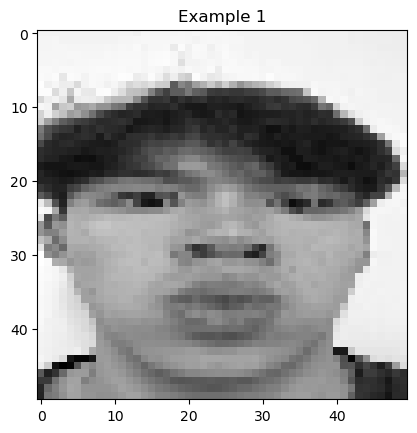

age: 20
gender: 0


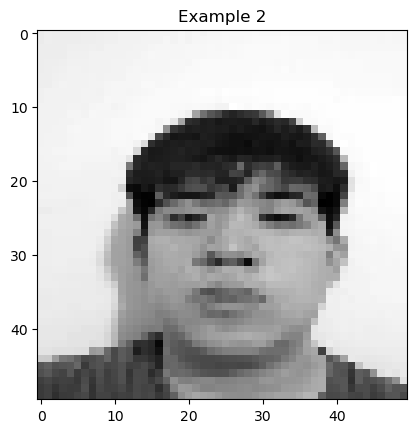

age: 20
gender: 0


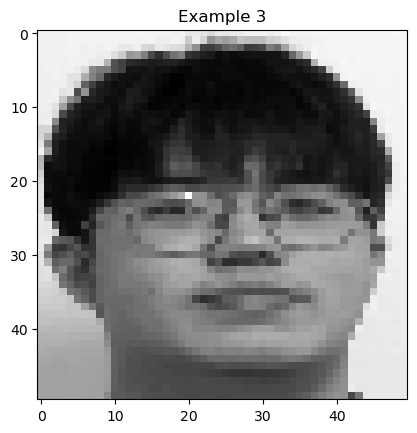

age: 21
gender: 0


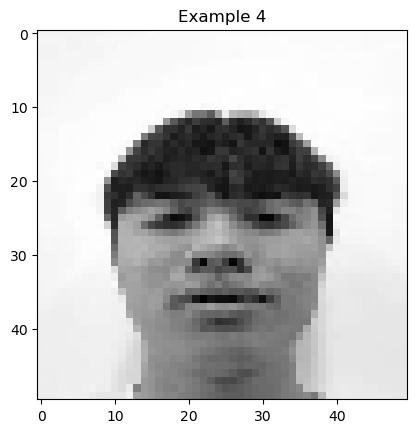

age: 21
gender: 0


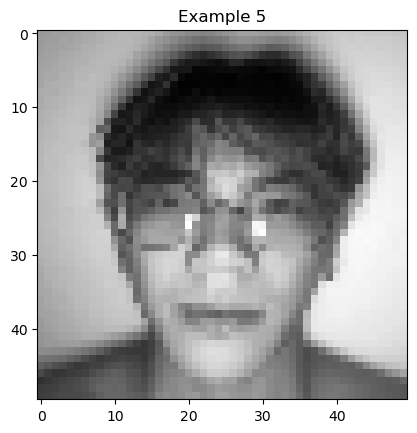

In [141]:
import glob
import os

Member_Faces = []
Member_Ages = []
Member_Genders = []

# Visualize some examples of resized images
for k, i in enumerate(glob.glob(r"FaceData1/*")):

    # Load image
    imagei = image.imread(i)
    print("age:", os.path.basename(i).split("_")[0])
    print("gender:", os.path.basename(i).split("_")[1])  # male 0, female 1
    Member_Ages.append(os.path.basename(i).split("_")[0])
    Member_Genders.append(os.path.basename(i).split("_")[1])

    # Convert to grayscale
    imagei_gray = color.rgb2gray(imagei)

    # Resize image
    image_rescaled = rescale(imagei_gray,0.25, anti_aliasing=False)

    # Visualize the resized images
    plt.figure()
    plt.imshow(image_rescaled, cmap='gray')
    plt.title(f"Example {k+1}")
    plt.show()

    # Flatten and append to the list
    Member_Faces.append(image_rescaled.flatten())


In [180]:
New_input = np.array(Member_Faces).astype(float)
New_age = np.array(Member_Ages).astype(float)/100
#Labels for Gender Prediction
New_gender = np.array(Member_Genders).astype(float)*2-1
New_gender

array([-1., -1., -1., -1., -1.])

In [181]:
X_new_train, X_new_test, y_age_new_train, y_age_new_test, y_gender_new_train, y_gender_new_test = train_test_split(New_input, New_age, New_gender, test_size=0.1, random_state=205)

In [182]:
# Demean (Data Preprocessing: Whitening Transformation)
X_train_new_mean = np.mean(X_new_train,axis=0)[None,:]

In [183]:
X_test = New_input
X_test_new_demean = X_test - X_train_new_mean

Q, s, PT = np.linalg.svd(X_train_new_demean)

e_values_new_sqr = s/X_new_train.shape[0]**0.5
X_test_whitten = X_test_new_demean@PT.T@np.linalg.inv(np.diag(e_values_new_sqr))


In [184]:
k = 250
X_test_new_whitten_reduced = X_test_new_demean@PT.T[:,:k]@np.linalg.inv(np.diag(e_values_sqr[:k]))


In [ ]:
y_new_pred, _, _ = predict_classification_SDG(X_test_new_whitten_reduced, W_hidden, W_output)
accuracy = np.sum(np.sign(y_gender_new_test) == np.sign(y_new_pred[:, 0])) / y_gender_new_test.shape[0]
print("Accuracy:", accuracy)

In [ ]:
y_pred_new_test,_,_ = predict_regression_SDG(X_test_new_whitten_reduced , W_hidden,W_output)
print(mean_squared_error(y_age_new_test,y_pred_new_test))